In [ ]:
# Décommenter si besoin
# !pip install xgboost seaborn scikit-learn pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Remplacer par le chemin de votre fichier CSV
df = pd.read_csv('job-automation-probability.csv')

print(" Données chargées")
print(f"Shape : {df.shape}")
df.head()

✅ Données chargées
Shape : (702, 13)


,_ - rank,_ - code,prob,Average annual wage,education,occupation,short occupation,len,probability,numbEmployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.950,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.950,74600,32890.0,74600,34920.0
1,517,51-9012,0.880,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.880,47160,38360.0,47160,41450.0
2,484,41-4012,0.850,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.850,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.029,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.029,202760,57270.0,202760,59800.0
4,620,51-4072,0.950,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.950,145560,30480.0,145560,32660.0


In [ ]:
# 1. Supprimer les colonnes dupliquées
# Colonnes présentes
print("Colonnes avant nettoyage :", df.columns.tolist())

# 'probability' est identique à 'prob' → suppression
if 'probability' in df.columns:
    df = df.drop(columns=['probability'])

# S'il y a deux fois 'average_ann_wage', on garde la dernière (la plus fiable)
if list(df.columns).count('average_ann_wage') > 1:
    # On récupère les indices
    cols = df.columns.tolist()
    first_idx = cols.index('average_ann_wage')
    df = df.drop(columns=[cols[first_idx]])  # supprime la première occurrence

# 2. Standardiser les noms de colonnes (minuscules + underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Colonnes après standardisation :", df.columns.tolist())

# 3. Gérer les valeurs manquantes
print("\nValeurs manquantes avant traitement :")
print(df.isnull().sum())

# Supprimer les lignes sans probabilité (cible)
df = df.dropna(subset=['prob'])

# Pour les colonnes numériques : remplacer par la médiane
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Pour les colonnes textuelles : remplacer par "Unknown"
text_cols = ['education', 'occupation', 'short_occupation']
for col in text_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna("Unknown", inplace=True)

print(f"\n✅ Après nettoyage : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Colonnes avant nettoyage : ['_ - rank', '_ - code', 'prob', 'Average annual wage', 'education', 'occupation', 'short occupation', 'len', 'probability', 'numbEmployed', 'median_ann_wage', 'employed_may2016', 'average_ann_wage']
Colonnes après standardisation : ['__-_rank', '__-_code', 'prob', 'average_annual_wage', 'education', 'occupation', 'short_occupation', 'len', 'numbemployed', 'median_ann_wage', 'employed_may2016', 'average_ann_wage']

Valeurs manquantes avant traitement :
__-_rank               0
__-_code               0
prob                   0
average_annual_wage    0
education              0
occupation             0
short_occupation       0
len                    0
numbemployed           0
median_ann_wage        0
employed_may2016       0
average_ann_wage       0
dtype: int64

✅ Après nettoyage : 702 lignes, 12 colonnes


,__-_rank,__-_code,prob,average_annual_wage,education,occupation,short_occupation,len,numbemployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.950,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,74600,32890.0,74600,34920.0
1,517,51-9012,0.880,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,47160,38360.0,47160,41450.0
2,484,41-4012,0.850,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.029,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,202760,57270.0,202760,59800.0
4,620,51-4072,0.950,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,145560,30480.0,145560,32660.0


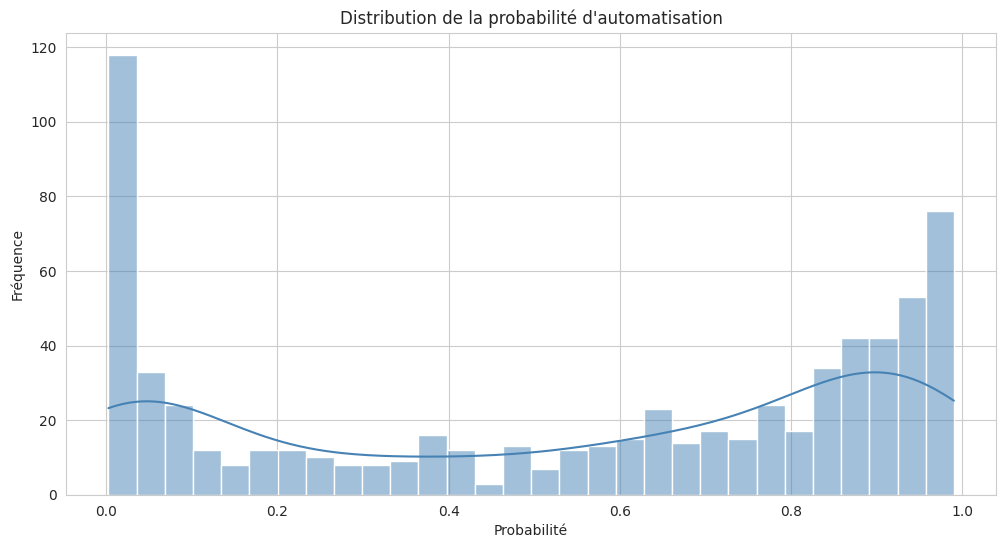

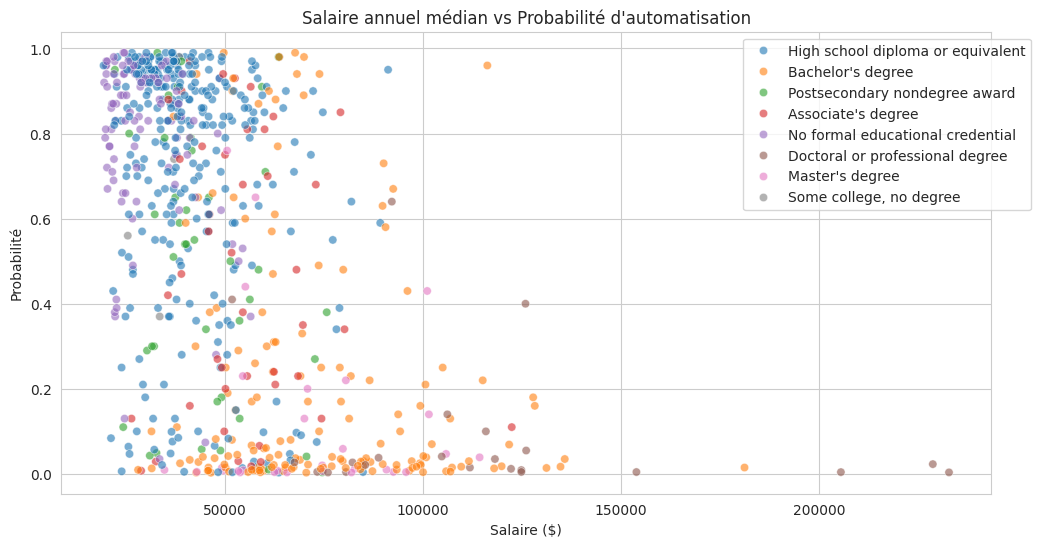

Corrélation probabilité / salaire : -0.530


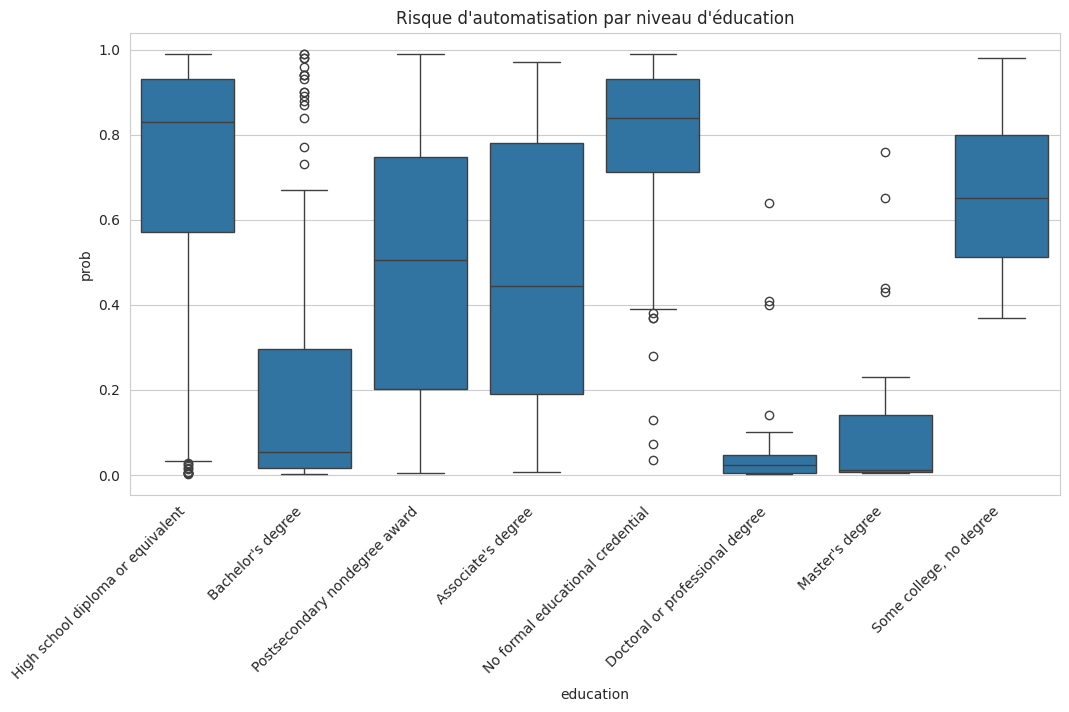

🔴 Top 10 des métiers les plus automatisables :
                                                   occupation  prob  median_ann_wage                         education
Photographic Process Workers and Processing Machine Operators  0.99          26470.0 High school diploma or equivalent
                   Title Examiners, Abstractors and Searchers  0.99          45800.0 High school diploma or equivalent
                                     Cargo and Freight Agents  0.99          41920.0 High school diploma or equivalent
                                     Mathematical Technicians  0.99          49660.0                 Bachelor's degree
                                       Insurance Underwriters  0.99          67680.0                 Bachelor's degree
                                          Library Technicians  0.99          32890.0     Postsecondary nondegree award
                                          New Accounts Clerks  0.99          34990.0 High school diploma or equivalent
 

In [ ]:
# Style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2.1 Distribution des probabilités d'automatisation
plt.figure()
sns.histplot(df['prob'], bins=30, kde=True, color='steelblue')
plt.title("Distribution de la probabilité d'automatisation")
plt.xlabel("Probabilité")
plt.ylabel("Fréquence")
plt.show()

# 2.2 Corrélation entre salaire et probabilité
wage_col = 'median_ann_wage' if 'median_ann_wage' in df.columns else 'average_ann_wage'
plt.figure()
sns.scatterplot(data=df, x=wage_col, y='prob', hue='education', alpha=0.6)
plt.title("Salaire annuel médian vs Probabilité d'automatisation")
plt.xlabel("Salaire ($)")
plt.ylabel("Probabilité")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

corr = df['prob'].corr(df[wage_col])
print(f"Corrélation probabilité / salaire : {corr:.3f}")

# 2.3 Impact du niveau d'éducation
plt.figure()
sns.boxplot(data=df, x='education', y='prob')
plt.xticks(rotation=45, ha='right')
plt.title("Risque d'automatisation par niveau d'éducation")
plt.show()

# 2.4 Top 10 des métiers les plus et moins automatisables
top_auto = df.nlargest(10, 'prob')[['occupation', 'prob', wage_col, 'education']]
bottom_auto = df.nsmallest(10, 'prob')[['occupation', 'prob', wage_col, 'education']]

print("🔴 Top 10 des métiers les plus automatisables :")
print(top_auto.to_string(index=False))

print("\n🟢 Top 10 des métiers les moins automatisables :")
print(bottom_auto.to_string(index=False))

In [ ]:
# 3.1 Extraire des mots-clés des colonnes 'occupation' et 'short_occupation'
# On crée une colonne 'occupation_clean' en minuscules
df['occupation_clean'] = df['occupation'].str.lower()

# Exemple : détection de quelques secteurs clés
def extract_keywords(text):
    keywords = []
    if pd.isna(text):
        return 'other'
    text = text.lower()
    if 'engineer' in text or 'technician' in text:
        keywords.append('technical')
    if 'manager' or 'supervisor' in text:
        keywords.append('management')
    if 'sales' in text or 'retail' in text:
        keywords.append('sales')
    if 'teacher' in text or 'education' in text:
        keywords.append('education')
    if 'health' in text or 'medical' in text or 'nurse' in text:
        keywords.append('healthcare')
    if 'construction' in text or 'mining' in text or 'extraction' in text:
        keywords.append('construction')
    if 'food' in text or 'cook' in text or 'restaurant' in text:
        keywords.append('food_service')
    return keywords[0] if keywords else 'other'

df['industry_category'] = df['occupation_clean'].apply(extract_keywords)

# 3.2 Créer des catégories de métiers (manuelle ou basée sur short_occupation)
# On peut aussi utiliser la longueur du titre ou un regroupement
df['job_family'] = df['short_occupation'].fillna('unknown')

# 3.3 Normaliser les salaires et le nombre d'employés
from sklearn.preprocessing import StandardScaler

scaler_wage = StandardScaler()
df['wage_normalized'] = scaler_wage.fit_transform(df[[wage_col]])

scaler_emp = StandardScaler()
df['employed_normalized'] = scaler_emp.fit_transform(df[['numbemployed']])

# 3.4 Créer une variable 'risk_category' (Faible, Moyen, Élevé)
def risk_cat(prob):
    if prob < 0.33:
        return 'Faible'
    elif prob < 0.66:
        return 'Moyen'
    else:
        return 'Élevé'

df['risk_category'] = df['prob'].apply(risk_cat)

# Vérification
print(df[['occupation', 'prob', 'risk_category']].head(10))

                                          occupation   prob risk_category
0  Grinding, Lapping, Polishing and Buffing Machi...  0.950         Élevé
1  Separating, Filtering, Clarifying, Precipitati...  0.880         Élevé
2  Sales Representatives, Wholesale and Manufactu...  0.850         Élevé
3  First-Line Supervisors of Transportation and M...  0.029        Faible
4  Molding, Coremaking and Casting Machine Setter...  0.950         Élevé
5  Extruding and Forming Machine Setters, Operato...  0.880         Élevé
6  Cutting, Punching and Press Machine Setters, O...  0.780         Élevé
7  Sales Representatives, Wholesale and Manufactu...  0.250        Faible
8  Drilling and Boring Machine Tool Setters, Oper...  0.940         Élevé
9  Extruding, Forming, Pressing and Compacting Ma...  0.930         Élevé


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encodage de la colonne 'education'
le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['education'])

# Sélection des features (on exclut les colonnes texte non encodées)
features = ['education_encoded', 'len', 'numbemployed', wage_col, 'employed_may2016', 'wage_normalized', 'employed_normalized']
# On peut aussi ajouter 'industry_category' encodé
le_cat = LabelEncoder()
df['industry_encoded'] = le_cat.fit_transform(df['industry_category'])
features.append('industry_encoded')

X = df[features]
y = df['prob']

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (561, 8), Test : (141, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# 1. Ne garder que les colonnes numériques (int ou float)
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

print("Colonnes numériques conservées :", X_train_num.columns.tolist())
print("Colonnes exclues (non numériques) :", [col for col in X_train.columns if col not in X_train_num.columns])

# 2. Imputation des NaN par la médiane
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_num)
X_test_imputed = imputer.transform(X_test_num)

# 3. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. Modèle
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Régression Linéaire ===")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Colonnes numériques conservées : ['education_encoded', 'len', 'numbemployed', 'median_ann_wage', 'wage_normalized', 'employed_normalized', 'industry_encoded']
Colonnes exclues (non numériques) : ['employed_may2016']
=== Régression Linéaire ===
RMSE : 0.3029
R²   : 0.3048


Colonnes utilisées : ['education_encoded', 'len', 'numbemployed', 'median_ann_wage', 'wage_normalized', 'employed_normalized', 'industry_encoded']
=== Random Forest ===
RMSE : 0.3015
R²   : 0.3112


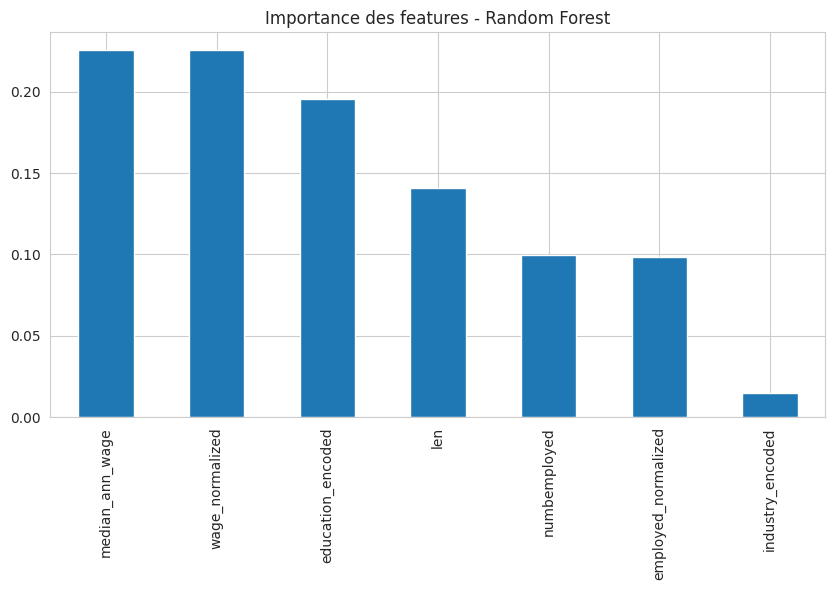

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ne garder que les colonnes numériques pour X_train et X_test
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

print("Colonnes utilisées :", X_train_num.columns.tolist())

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_num, y_train)
y_pred_rf = rf.predict(X_test_num)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

# Importance des features
importances = pd.Series(rf.feature_importances_, index=X_train_num.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
importances.plot(kind='bar')
plt.title("Importance des features - Random Forest")
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Convertir toutes les colonnes en numérique (forcer les types)
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in X_train_xgb.columns:
    # Si la colonne est de type object, on tente de la convertir en nombre
    if X_train_xgb[col].dtype == 'object':
        X_train_xgb[col] = pd.to_numeric(X_train_xgb[col], errors='coerce')
        X_test_xgb[col] = pd.to_numeric(X_test_xgb[col], errors='coerce')

# 2. Supprimer les colonnes qui sont restées non numériques (si certaines n'ont pas pu être converties)
#    On ne garde que les colonnes numériques (float ou int)
numeric_cols = X_train_xgb.select_dtypes(include=[np.number]).columns
X_train_xgb = X_train_xgb[numeric_cols]
X_test_xgb = X_test_xgb[numeric_cols]

print("Colonnes utilisées :", X_train_xgb.columns.tolist())

# 3. Imputer les valeurs manquantes (NaN) avec la médiane
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_xgb)
X_test_imp = imputer.transform(X_test_xgb)

# 4. XGBoost (ne nécessite pas de normalisation)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_imp, y_train)
y_pred_xgb = xgb_model.predict(X_test_imp)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

Colonnes utilisées : ['education_encoded', 'len', 'numbemployed', 'median_ann_wage', 'employed_may2016', 'wage_normalized', 'employed_normalized', 'industry_encoded']
=== XGBoost ===
RMSE : 0.3193
R²   : 0.2273


In [ ]:
# 1. Préparer des versions numériques propres de X_train et X_test
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

# 2. Imputer les NaN (si besoin)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp = imputer.transform(X_test_num)

# 3. Comparaison des modèles (en utilisant les données propres)
# Recalculer les prédictions sur ces données propres
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Régression linéaire avec scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest (pas besoin de scaling)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_imp, y_train)
y_pred_rf = rf.predict(X_test_imp)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_imp, y_train)
y_pred_xgb = xgb_model.predict(X_test_imp)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# DataFrame de comparaison
results = pd.DataFrame({
    'Modèle': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})
print(results)

# 4. Optimisation Random Forest avec GridSearchCV (utiliser X_train_imp)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_imp, y_train)   # ← ici on utilise la version numérique et imputée

print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleur R² validation : {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_imp)
print(f"R² final sur test : {r2_score(y_test, y_pred_best):.4f}")

              Modèle      RMSE        R²
0  Linear Regression  0.302885  0.304845
1      Random Forest  0.301506  0.311162
2            XGBoost  0.317124  0.237951
Meilleurs paramètres : {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Meilleur R² validation : 0.4005
R² final sur test : 0.3825


In [ ]:
# Sauvegarde du modèle final (optionnel)
import joblib
joblib.dump(best_rf, 'best_random_forest_model.pkl')
print("✅ Modèle sauvegardé")

# Aperçu final des données enrichies
df[['occupation', 'prob', 'risk_category', 'industry_category', 'wage_normalized']].head()

✅ Modèle sauvegardé


,occupation,prob,risk_category,industry_category,wage_normalized
0,"Grinding, Lapping, Polishing and Buffing Machi...",0.950,Élevé,management,-0.686235
1,"Separating, Filtering, Clarifying, Precipitati...",0.880,Élevé,management,-0.482842
2,"Sales Representatives, Wholesale and Manufactu...",0.850,Élevé,management,0.215460
3,First-Line Supervisors of Transportation and M...,0.029,Faible,management,0.220294
4,"Molding, Coremaking and Casting Machine Setter...",0.950,Élevé,management,-0.775847
